## Training script

In [1]:
# Jupyter notebook auto reload
%load_ext autoreload
%autoreload 2

import json
import torch
import torch.nn as nn
import torch.optim as optim
from char_tokenizer import TinyArithmeticCharTokenizer
from tiny_transformer import TinyArithmeticTransformer
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
from IPython.display import clear_output, display
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")

# configuration 1: training with this config and 10K samples caused model to hit a wall...
# batch_size = 64
# d_model = 64
# max_seq_len = 256
# num_heads = 4

# configuration 2: trying bigger model size with 1mm samples dataset
batch_size = 256
d_model = 512
max_seq_len = 256
num_heads = 8

train_percent = 0.80
val_percent   = 0.10
test_percent  = 0.10

rand_seed = 42

Training on device: cuda


### Loading dataset, adding "=" between input and output, tokenization, and adding padding

In [2]:
tokenizer = TinyArithmeticCharTokenizer()

with open("dataset.json", "r") as f:
    raw_data = json.load(f)

tokenized_sequences = []
for expression, result in raw_data:
    # debugging: trying out reverse string for the output
    reversed_result = str(result)[::-1]
    
    full_str = f"{expression}={reversed_result}"
    eos_token_id = tokenizer.char_to_int["<eos>"]
    encoded_ids = tokenizer.encode(full_str)
    encoded_ids.append(eos_token_id)
    tokenized_sequences.append(encoded_ids)

pad_id = tokenizer.char_to_int["<pad>"]

padded_sequences = []
for seq in tokenized_sequences:
    if len(seq) < max_seq_len:
        seq = seq + [pad_id] * (max_seq_len - len(seq))
    else:
        seq = seq[:max_seq_len]
    padded_sequences.append(seq)

dataset_tensor = torch.tensor(padded_sequences, dtype=torch.long)

print(f"Dataset securely loaded in-memory. Matrix shape: {dataset_tensor.shape}")
print(f"The <eos> token id is: {tokenizer.char_to_int['<eos>']}")
print(dataset_tensor[:1])

Dataset securely loaded in-memory. Matrix shape: torch.Size([1000000, 256])
The <eos> token id is: 19
tensor([[11,  8,  4, 15,  8, 16, 12, 16,  9,  4, 15,  6,  7, 16, 10, 16,  9,  2,
         15,  4,  1, 16, 11, 16, 11,  1,  3, 15,  2,  3, 16, 12, 16,  8,  7, 15,
          4, 16, 13, 16, 11,  4,  3, 15,  9,  9, 16, 11, 16, 11,  2, 15,  2, 16,
         10, 16, 11,  5,  8, 15,  7,  6, 16, 10, 16, 11,  8,  7, 15,  6,  4, 16,
         12, 16, 11,  5, 15,  4,  1, 16, 11, 16, 11,  2,  0, 15,  4,  2, 14,  9,
         15,  3,  2,  5,  7, 11, 19, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17,
         17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17,
         17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17,
         17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17,
         17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17,
         17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17,
       

### Preparing training, validation, testing datasets.

In [3]:
total_rows = dataset_tensor.size(0)

train_size = int(train_percent * total_rows)
val_size   = int(val_percent * total_rows)
test_size  = total_rows - train_size - val_size

train_subset, val_subset, test_subset = random_split(
    dataset_tensor, 
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(rand_seed)
)

train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_subset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_subset, batch_size=batch_size, shuffle=False)

print(f"Train Loader: {len(train_loader)} batches (Total: {len(train_subset)} shuffled rows)")
print(f"Val Loader:   {len(val_loader)} batches (Total: {len(val_subset)} shuffled rows)")
print(f"Test Loader:  {len(test_loader)} batches (Total: {len(test_subset)} shuffled rows)")

Train Loader: 3125 batches (Total: 800000 shuffled rows)
Val Loader:   391 batches (Total: 100000 shuffled rows)
Test Loader:  391 batches (Total: 100000 shuffled rows)


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")

vocab_size   = tokenizer.vocab_size  
eq_token_id  = tokenizer.char_to_int["="]     
pad_token_id = tokenizer.char_to_int["<pad>"] 

model     = TinyArithmeticTransformer(vocab_size=vocab_size, d_model=d_model, max_seq_len=max_seq_len, num_heads=num_heads)

# if torch.cuda.device_count() > 1:
#     print(f"Using {torch.cuda.device_count()} GPU via DataParallel!")
#     model = nn.DataParallel(model)

model = model.to(device)
    
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.01)
loss_fct  = nn.CrossEntropyLoss(reduction='none')

train_loss_history = []
val_loss_history = []

Training on device: cuda


In [5]:
for name, param in model.named_parameters():
    print(name, param.shape)

token_embedding_layer.weight torch.Size([20, 512])
pre_attention_layernorm.weight torch.Size([512])
pre_attention_layernorm.bias torch.Size([512])
multi_head_attention.q_linear.weight torch.Size([512, 512])
multi_head_attention.q_linear.bias torch.Size([512])
multi_head_attention.k_linear.weight torch.Size([512, 512])
multi_head_attention.k_linear.bias torch.Size([512])
multi_head_attention.v_linear.weight torch.Size([512, 512])
multi_head_attention.v_linear.bias torch.Size([512])
multi_head_attention.out_linear.weight torch.Size([512, 512])
multi_head_attention.out_linear.bias torch.Size([512])
pre_ffn_layernorm.weight torch.Size([512])
pre_ffn_layernorm.bias torch.Size([512])
ffn.0.weight torch.Size([2048, 512])
ffn.0.bias torch.Size([2048])
ffn.2.weight torch.Size([2048, 2048])
ffn.2.bias torch.Size([2048])
ffn.4.weight torch.Size([512, 2048])
ffn.4.bias torch.Size([512])
output_linear.weight torch.Size([20, 512])
output_linear.bias torch.Size([20])


In [6]:
sd = model.state_dict()

for k in sd.keys():
    print(k)

token_embedding_layer.weight
positional_encoding.pe
pre_attention_layernorm.weight
pre_attention_layernorm.bias
multi_head_attention.q_linear.weight
multi_head_attention.q_linear.bias
multi_head_attention.k_linear.weight
multi_head_attention.k_linear.bias
multi_head_attention.v_linear.weight
multi_head_attention.v_linear.bias
multi_head_attention.out_linear.weight
multi_head_attention.out_linear.bias
pre_ffn_layernorm.weight
pre_ffn_layernorm.bias
ffn.0.weight
ffn.0.bias
ffn.2.weight
ffn.2.bias
ffn.4.weight
ffn.4.bias
output_linear.weight
output_linear.bias


#### Helper function to compute the loss mask. Later when calculating loss, since our prefix inputs is full attention and sees every token, we dont want to calculate loss for prefix tokens. We also don't want to calculate loss for <pad> after our <eos>. This loss mask will produce a [0, 1] float dtype mask so we zero out the loss from tokens we dont care about, leaving only the loss updates for the output tokens and <eos>.

In [7]:
def compute_loss_mask(targets: torch.Tensor, eq_token_id: int, pad_token_id: int) -> torch.Tensor:
    batch_size, seq_len = targets.shape
    
    eq_indices = (targets == eq_token_id).int().argmax(dim=-1).view(batch_size, 1)
    pos_grid = torch.arange(seq_len, device=targets.device).view(1, seq_len)
    
    is_after_eq = (pos_grid > eq_indices)
    is_not_pad  = (targets != pad_token_id)
    
    loss_mask = (is_after_eq & is_not_pad).float().view(-1)
    return loss_mask


In [8]:
def plot_live_loss(train_history, val_history, current_epoch, total_target_epochs):
    clear_output(wait=True)
    
    fig, ax = plt.subplots(figsize=(8, 5))
    epochs_range = range(1, len(train_history) + 1)
    
    ax.plot(epochs_range, train_history, label='Training Loss', color='royalblue', linewidth=2, marker='o')
    ax.plot(epochs_range, val_history, label='Validation Loss', color='darkorange', linewidth=2, marker='s')
    
    ax.set_title('Live Training and Validation Loss', fontsize=14, fontweight='bold')
    ax.set_xlabel('Epochs', fontsize=12)
    ax.set_ylabel('Cross-Entropy Loss', fontsize=12)
    ax.set_xticks(epochs_range)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(fontsize=11)
    
    plt.tight_layout()
    display(fig)
    plt.close(fig)
    
    print(f"Latest Stats -> Epoch {current_epoch:02d}/{total_target_epochs:02d} | "
          f"Train Loss: {train_history[-1]:.4f} | Val Loss: {val_history[-1]:.4f}")


def train_model(num_epochs_to_add: int):
    start_epoch = len(train_loss_history)
    target_epoch = start_epoch + num_epochs_to_add

    scaler = torch.amp.GradScaler('cuda') # Automatic Mixed Precision
    
    for epoch in range(start_epoch, target_epoch):
        model.train()
        total_train_loss = 0.0
        
        for batch_sequences in tqdm(train_loader, desc=f"Epoch {epoch+1} Training"):
            batch_sequences = batch_sequences.to(device)
            
            inputs  = batch_sequences[:, :-1].contiguous()
            targets = batch_sequences[:, 1:].contiguous()

            with torch.amp.autocast('cuda', dtype=torch.float16):
                attn_mask = model.compute_prefix_lm_mask(inputs, eq_token_id)
                
                optimizer.zero_grad()
                logits = model(inputs, mask=attn_mask)
                
                raw_loss          = loss_fct(logits.view(-1, vocab_size), targets.view(-1))
                loss_mask         = compute_loss_mask(targets, eq_token_id, pad_token_id)
                num_active_tokens = loss_mask.sum()
                
                loss = (raw_loss * loss_mask).sum() / max(num_active_tokens.item(), 1.0)
            
            # 3. Scales loss, calls backward(), and unscales gradients behind the scenes
            scaler.scale(loss).backward()
            
            # 4. Step the optimizer via the scaler
            scaler.step(optimizer)
            
            # 5. Update the scale factor for the next batch
            scaler.update()
            
            total_train_loss += loss.item()
            
        model.eval()
        total_val_loss = 0.0
        with torch.no_grad():
            for batch_sequences in tqdm(val_loader, desc=f"Epoch {epoch+1} Validation"):
                batch_sequences = batch_sequences.to(device)
                inputs  = batch_sequences[:, :-1].contiguous()
                targets = batch_sequences[:, 1:].contiguous()
                
                attn_mask = model.compute_prefix_lm_mask(inputs, eq_token_id)
                logits    = model(inputs, mask=attn_mask)
                
                raw_loss  = loss_fct(logits.view(-1, vocab_size), targets.view(-1))
                loss_mask = compute_loss_mask(targets, eq_token_id, pad_token_id)
                
                val_loss = (raw_loss * loss_mask).sum() / max(loss_mask.sum().item(), 1.0)
                total_val_loss += val_loss.item()
                
        avg_train_loss = total_train_loss / len(train_loader)
        avg_val_loss   = total_val_loss / len(val_loader)
        
        train_loss_history.append(avg_train_loss)
        val_loss_history.append(avg_val_loss)

        # plotting losses
        plot_live_loss(
            train_history=train_loss_history, 
            val_history=val_loss_history, 
            current_epoch=epoch + 1, 
            total_target_epochs=target_epoch
        )

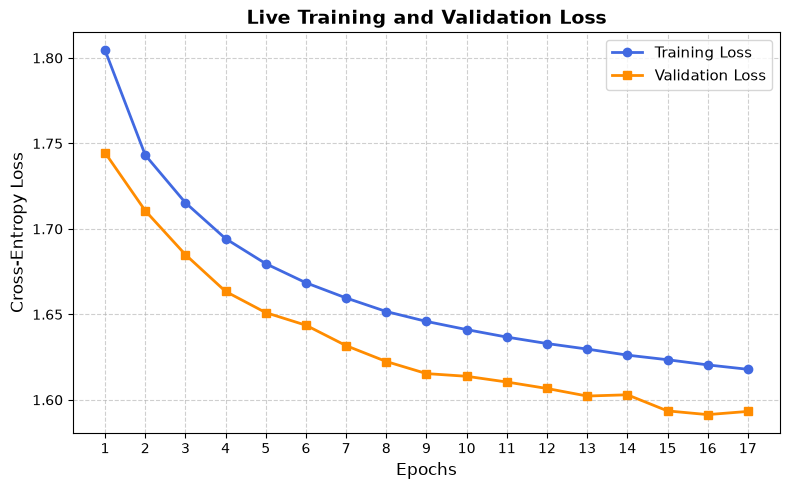

Latest Stats -> Epoch 17/17 | Train Loss: 1.6179 | Val Loss: 1.5932


In [16]:
train_model(num_epochs_to_add=2) 

In [17]:
def ask_transformer(expression: str, max_gen_tokens: int = 15):
    """
    Takes a string like '12 + 5', formats it, and prints the model's prediction.
    """
    model.eval()
    
    if not expression.endswith("="):
        expression += "="
        
    try:
        input_ids = [tokenizer.char_to_int[char] for char in expression]
    except KeyError as e:
        print(f"Error: Character {e} is not in your tokenizer's vocabulary!")
        return
        
    input_tensor = torch.tensor([input_ids], device=device)
    
    generated_tokens = []
    
    with torch.no_grad():
        for _ in range(max_gen_tokens):
            attn_mask = model.compute_prefix_lm_mask(input_tensor, eq_token_id)
            
            logits = model(input_tensor, mask=attn_mask)
            
            next_token_logits = logits[0, -1, :]
            next_token = next_token_logits.argmax().item()
            
            if next_token == tokenizer.char_to_int.get("<eos>") or next_token == pad_token_id:
                break
                
            generated_tokens.append(next_token)
            
            next_tensor = torch.tensor([[next_token]], device=device)
            input_tensor = torch.cat([input_tensor, next_tensor], dim=1)
            
    predicted_answer = "".join([tokenizer.int_to_char[t] for t in generated_tokens])[::-1]
    
    print(f"Prompt: {expression}")
    print(f"Model Output: {predicted_answer}\n")

In [18]:
ask_transformer("100 + 100")
ask_transformer("1 + 1")
ask_transformer("2 * 2")
ask_transformer("2 - 2")
ask_transformer("90 + 2 * 5")
ask_transformer("11 + 12 + 13 * 10")
ask_transformer("6 * 6 + 4")
ask_transformer("1 + 2 + 3 + 4 + 5")

Prompt: 100 + 100=
Model Output: 20.6

Prompt: 1 + 1=
Model Output: 10.3

Prompt: 2 * 2=
Model Output: 239

Prompt: 2 - 2=
Model Output: -4.9

Prompt: 90 + 2 * 5=
Model Output: 1399.9

Prompt: 11 + 12 + 13 * 10=
Model Output: 226.66

Prompt: 6 * 6 + 4=
Model Output: 3189.8

Prompt: 1 + 2 + 3 + 4 + 5=
Model Output: 64.3

